# Topological Sholl descriptors of ferret corticogeniculate neurons

Step functions are computed here from the SWC reconstructions. Every figure
and every statistical test reported in the paper is reproduced by calling
the same analysis code that generated it, on the same data, not by a
separate reimplementation.

```
SWC -> step functions -> L1 distance per descriptor
    -> weighted combination -> dendrogram
```

and, for comparison, the same neurons through conventional morphometrics:

```
L-Measure variables -> per object -> standardised -> Euclidean -> dendrogram
```

Method: Khalil R, Kallel S, Farhat A, Dlotko P. Topological Sholl descriptors
for neuronal clustering and classification. *PLoS Comput Biol.* 2022;18(6):e1010229.

---

**Running it.** Work through the cells in order, top to bottom. Reading the
reconstructions takes about 85 seconds; computing descriptors for the
demonstration neurons about 20. Both keep their result in the session, so
re-running them while you explore costs nothing. Everything else returns in
a second or two.


In [1]:
import os, sys, time, pickle, json
from pathlib import Path

REPO = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
os.chdir(REPO); sys.path.insert(0, str(REPO))

RECOMPUTE_ALL = False   # True derives every one of the 117 neurons here
N_DEMO = 6

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from scipy.cluster.hierarchy import linkage, fcluster
from scipy.spatial.distance import squareform, pdist
from scipy.cluster.hierarchy import cophenet
from sklearn.metrics import (adjusted_rand_score, silhouette_score,
                            normalized_mutual_info_score)
from sklearn.preprocessing import StandardScaler

import config
config.PLOT_STEP_FUNCTION = False   # otherwise one PNG per neuron per descriptor
config.PLOT_NEURON = False

from analysis.supporting._common import (load_matrices, load_classes,
    load_detection_weights, combine as common_combine, ward_clusters)

RUN = REPO / 'figures' / 'results'
PICKLES, PLOTS = RUN / 'pickles', RUN / 'plots'

plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False,
                     'axes.spines.right': False})
TIER = {'V1-V2': '#1a80bb', 'PMLS-PLLS': '#ea801c'}
print('repository:', REPO)


repository: C:\Users\ahmad\Documents\GitHub\Briggs_V1_V2_PMLS_PLLS\ferret-cg-morphology


## 1. From reconstructions to step functions

`process_swc_directory()` reads every `.swc` under `data/<PROJECT_NAME>/`,
strips the axon, and normalises each neuron's radial coordinate by its own
maximum distance from the soma. Class labels come from the folder each
file sits in.


In [2]:
from neurotopo.neuron_processor import process_swc_directory
import neurotopo.descriptors as d

if 'neuron_data' not in dir():
    t0 = time.time()
    neuron_data, classes, standardisation_report = process_swc_directory()
    classes = classes.set_index('neuron_name')
    print(f'read {len(neuron_data)} reconstructions in {time.time()-t0:.0f}s')
else:
    print(f'reusing {len(neuron_data)} reconstructions already parsed in this session')

print()
print(classes['class'].value_counts().to_string())


Processing neuron 1 out of 117


Processing neuron 2 out of 117


Processing neuron 3 out of 117


Processing neuron 4 out of 117


Processing neuron 5 out of 117


...

Processing neuron 114 out of 117


Processing neuron 115 out of 117


Processing neuron 116 out of 117


Processing neuron 117 out of 117


read 117 reconstructions in 138s

class
V1-V2        67
PMLS-PLLS    50


In [3]:
# The seven descriptors used in the paper. Each returns a list of
# (radius, value) pairs: a step function on [0, 1]. Spread and Energy
# return a tuple whose first element is that function.
DESCRIPTOR_FUNCTIONS = {
    'Tortuosity':        d.calculate_tortuosity,
    'Branching_Pattern': d.calculate_branching_pattern,
    'Wiring':            d.calculate_wiring_descriptor,
    'Flux':              d.calculate_flux,
    'Leaf':              d.calculate_leaf,
    'Spread':            d.calculate_spread_descriptor,
    'Energy':            d.calculate_energy,
}

def step_functions_for(neuron):
    out = {}
    for name, fn in DESCRIPTOR_FUNCTIONS.items():
        result = fn(neuron)
        out[name] = result[0] if isinstance(result, tuple) else result
    return out

demo = (list(classes[classes['class'] == 'V1-V2'].index[:N_DEMO // 2])
        + list(classes[classes['class'] == 'PMLS-PLLS'].index[:N_DEMO // 2]))

if 'demo_fns' not in dir():
    t0 = time.time()
    demo_fns = {n: step_functions_for(neuron_data[n]) for n in demo}
    elapsed = time.time() - t0
else:
    elapsed = float('nan')
print(f'computed 7 descriptors for {len(demo)} neurons in {elapsed:.0f}s')


computed 7 descriptors for 6 neurons in 36s


The paper shows step-function panels for two descriptors, one representative
neuron per tier: **Leaf** (Figure 2) and **Spread** (Figure 3). Reproduced
below by calling `neurotopo.descriptors.calculate_leaf` and
`calculate_spread_descriptor` directly on the same four neurons the
manuscript used, with plotting turned on — the actual plotting function
(`plot_step_function_leaf`), not a reimplementation, so the markers (red
bifurcations, green terminations, blue primary-branch or soma points) match
exactly. That function saves a PNG rather than returning a figure, so the
cell displays the file it just wrote.


In [4]:
if RECOMPUTE_ALL:
    t0 = time.time()
    descriptors = {name: {} for name in DESCRIPTOR_FUNCTIONS}
    for i, (n, neuron) in enumerate(neuron_data.items(), 1):
        for name, fn in step_functions_for(neuron).items():
            descriptors[name][n] = fn
        if i % 20 == 0:
            print(f'  {i}/{len(neuron_data)}  ({time.time()-t0:.0f}s)')
    print(f'computed from SWC in {(time.time()-t0)/60:.1f} min')
else:
    with (RUN / 'all_descriptors.pkl').open('rb') as fh:
        descriptors = pickle.load(fh)
    print('loaded cached step functions')
    same = all(list(descriptors[name][n]) == list(demo_fns[n][name])
               for n in demo for name in DESCRIPTOR_FUNCTIONS)
    print('cache matches freshly computed step functions:', same)

print(f'{len(descriptors)} descriptors x {len(next(iter(descriptors.values())))} neurons')


loaded cached step functions
cache matches freshly computed step functions: True
7 descriptors x 117 neurons


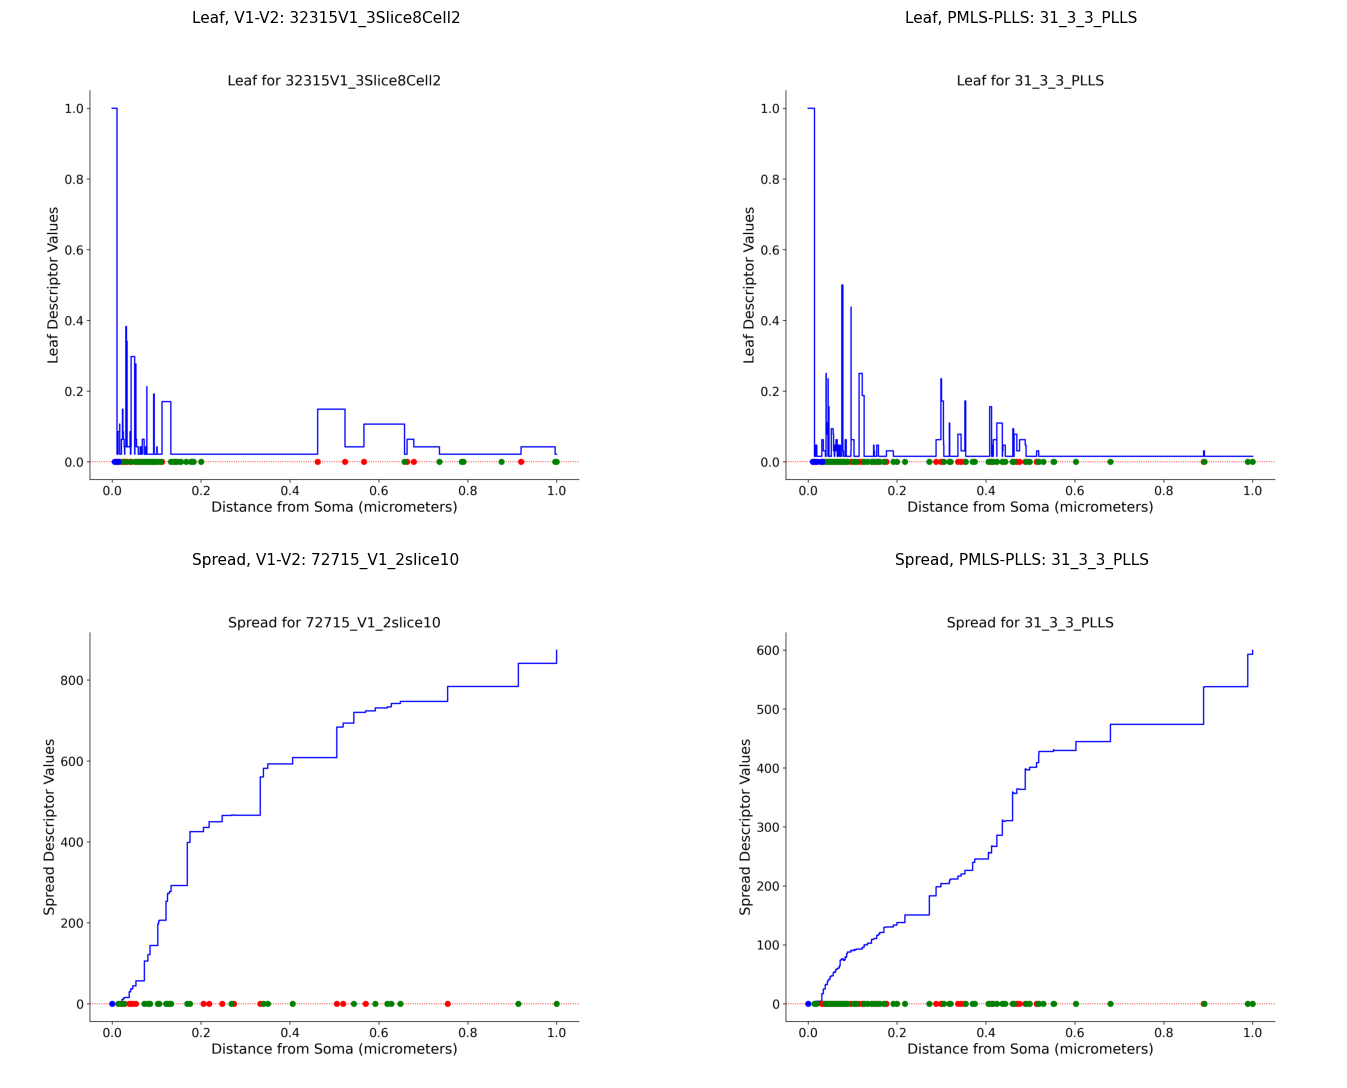

In [5]:
# The exact neurons the manuscript figures were drawn from (identified by
# reading the title baked into each published panel).
REPRESENTATIVE = {
    ('Leaf',   'V1-V2'):     '32315V1_3Slice8Cell2',
    ('Leaf',   'PMLS-PLLS'): '31_3_3_PLLS',
    ('Spread', 'V1-V2'):     '72715_V1_2slice10',
    ('Spread', 'PMLS-PLLS'): '31_3_3_PLLS',
}

config.PLOT_STEP_FUNCTION = True
for (descriptor_name, tier), neuron_name in REPRESENTATIVE.items():
    if descriptor_name == 'Leaf':
        d.calculate_leaf(neuron_data[neuron_name])
    else:
        d.calculate_spread_descriptor(neuron_data[neuron_name])
config.PLOT_STEP_FUNCTION = False

fig, axes = plt.subplots(2, 2, figsize=(13, 10))
for ax, ((descriptor_name, tier), neuron_name) in zip(axes.ravel(), REPRESENTATIVE.items()):
    saved = (Path(config.DESCRIPTORS_DIRECTORY) / 'step_functions'
            / f'{descriptor_name.lower()}_step_functions'
            / f'{tier}_{neuron_name}_{descriptor_name.lower()}.png')
    ax.imshow(mpimg.imread(saved)); ax.axis('off')
    ax.set_title(f'{descriptor_name}, {tier}: {neuron_name}', fontsize=10)
fig.tight_layout(); plt.show()


## 2. How independent are the seven descriptors?

The descriptors are not fully independent, so their correlations matter for
interpreting the combined distance. Spearman correlations among the seven
descriptor distance matrices, over all 6786 neuron pairs, computed by the
same reporting function the pipeline uses
(`write_descriptor_distance_dependence_report`).


In [6]:
from neurotopo.distances import write_descriptor_distance_dependence_report

matrices = load_matrices()
dependence = write_descriptor_distance_dependence_report(matrices, output_directory=None)
spearman = dependence['spearman']
display(spearman.style.format('{:.3f}').background_gradient(cmap='RdBu_r', vmin=-1, vmax=1))

pairs = dependence['pairs'].copy()
pairs = pairs[pairs['descriptor_a'] != pairs['descriptor_b']]
strongest = pairs.reindex(pairs['spearman_rho'].abs().sort_values(ascending=False).index).head(3)
print('strongest associations:')
print(strongest[['descriptor_a', 'descriptor_b', 'spearman_rho']].to_string(index=False))


,Tortuosity,Branching_Pattern,Wiring,Flux,Leaf,Spread,Energy
Tortuosity,1.000,-0.007,0.144,0.040,-0.046,0.140,-0.022
Branching_Pattern,-0.007,1.000,0.376,0.610,0.118,0.061,0.551
Wiring,0.144,0.376,1.000,0.322,0.188,0.137,0.142
Flux,0.040,0.610,0.322,1.000,-0.050,0.126,0.500
Leaf,-0.046,0.118,0.188,-0.050,1.000,-0.033,0.020
Spread,0.140,0.061,0.137,0.126,-0.033,1.000,0.031
Energy,-0.022,0.551,0.142,0.500,0.020,0.031,1.000


strongest associations:
     descriptor_a descriptor_b  spearman_rho
Branching_Pattern         Flux      0.609776
Branching_Pattern       Energy      0.550899
             Flux       Energy      0.499575


## 3. Distance matrices and how they are combined

The L1 distance between two step functions is the area between them, so one
metric serves every descriptor. They cannot simply be added: the
descriptors carry different physical units, and their mean pairwise
distances differ by orders of magnitude, so a raw sum would be decided by
units rather than by shape. Each matrix is divided by its mean off-diagonal
distance first, then weighted by its detection rate.


In [7]:
weights = load_detection_weights()
print('detection weights (%)')
print(pd.Series(weights).round(1).sort_values(ascending=False).to_string())

combined = common_combine(matrices, list(matrices), 'mean', weights)
stored = pd.read_pickle(PICKLES / 'combined_detection_weighted_matrix.pkl')
combined = combined.loc[stored.index, stored.columns]
print()
print('combined:', combined.shape)
print('matches the pipeline output:', np.allclose(combined.values, stored.values))


detection weights (%)
Spread               85.0
Flux                 82.8
Energy               77.5
Branching_Pattern    76.9
Tortuosity           71.3
Leaf                 68.7
Wiring               67.1

combined: (117, 117)
matches the pipeline output: True


## 4. Dendrograms

Both dendrograms below are produced by `DendrogramAnalysis`, the same class
the manuscript figures came from: Ward linkage, an automatically detected
colour-threshold (the largest gap between successive merge distances), and
a coloured bar under the leaves showing each neuron's true anatomical
class. The figure is generated fresh in this cell and then displayed, not
loaded from a previous run.


Detected a distance matrix.


Explained variance by PC1 and PC2: 65.61%, 34.39%
Average class confidence: 0.888
Classification accuracy in PCA space: 0.957


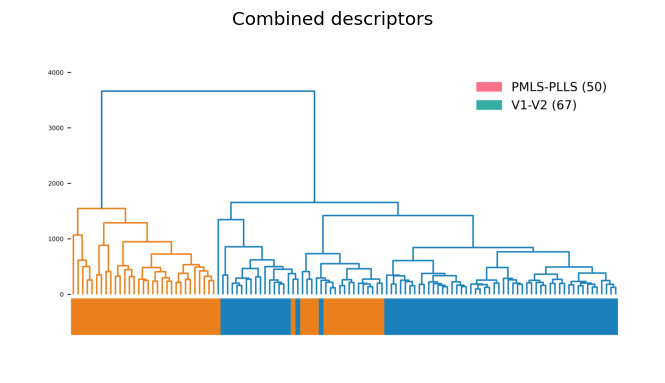

In [8]:
from analysis.data_analysis import DendrogramAnalysis

labels = classes.loc[combined.index, 'class'].to_numpy()
# .loc with combined.index (which is unnamed) would otherwise silently
# overwrite classes' own 'neuron_name' index name with None.
class_df_d = classes.loc[combined.index].rename_axis('neuron_name').reset_index()
class_df_d['class_color'] = class_df_d['class'].map(TIER)

dendro_d = DendrogramAnalysis(
    data=combined, neuron_class_df=class_df_d.copy(),
    save_directory=str(PLOTS), descriptor_name='notebook_descriptor_combined',
    is_distance_matrix=True, cutoff_dist=0,
)
assign_d = dendro_d.run_analysis()
img_path = PLOTS / 'notebook_descriptor_combined_dendrogram_with_bar.png'
plt.figure(figsize=(10, 4)); plt.imshow(mpimg.imread(img_path)); plt.axis('off')
plt.title('Combined descriptors'); plt.show()


In [9]:
ari_d = adjusted_rand_score(labels, assign_d['dendrogram_cluster'].to_numpy())
print(f'ARI vs anatomical tier: {ari_d:.4f}')
print(pd.crosstab(assign_d['dendrogram_cluster'], assign_d['class']).to_string())


ARI vs anatomical tier: 0.4497
class               PMLS-PLLS  V1-V2
dendrogram_cluster                  
0.0                        31      0
1.0                        19     67


### The same neurons through conventional morphometrics

L-Measure variables, expressed per object rather than as tree-wide totals
(so a variable measures shape, not neuron size), standardised, and compared
by Euclidean distance with Ward linkage — the method the paper states for
this comparison.


In [10]:
from analysis.lmeasure_analysis import to_per_object
import neurotopo.utils as utl

lm = pd.read_csv(REPO / 'data' / 'Briggs' / 'lmeasure_data.csv')
lm['Filename'] = (lm['Filename'].str.replace(r'\.swc$', '', regex=True)
                                .str.replace('.CNG', '', regex=False)
                                .str.replace(r'[ .\-]', '_', regex=True))
lm = lm.set_index('Filename')

numeric = lm.select_dtypes(include=['number'])
numeric = to_per_object(numeric)
numeric = utl.drop_constant_and_low_variance_columns(numeric)
numeric = numeric.loc[[n for n in combined.index if n in numeric.index]]
print(f'{numeric.shape[1]} L-Measure variables, {len(numeric)} of {len(combined)} neurons matched')

scaled = pd.DataFrame(StandardScaler().fit_transform(numeric),
                      index=numeric.index, columns=numeric.columns)
lm_distance = pd.DataFrame(squareform(pdist(scaled.values, metric='euclidean')),
                           index=numeric.index, columns=numeric.index)


38 L-Measure variables, 117 of 117 neurons matched


Detected a distance matrix.


Explained variance by PC1 and PC2: 57.39%, 42.61%
Average class confidence: 0.925
Classification accuracy in PCA space: 0.932


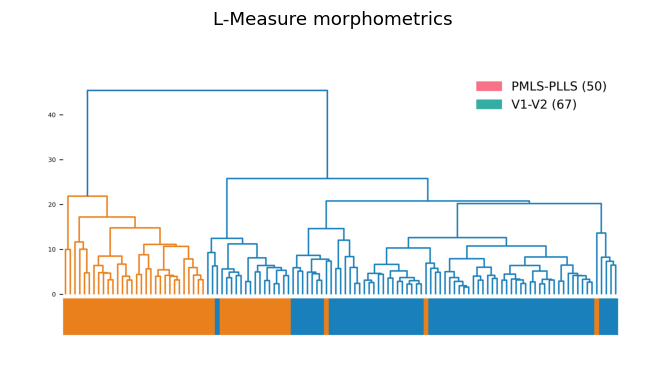

ARI vs anatomical tier: 0.4266


In [11]:
class_df_m = classes.loc[lm_distance.index].rename_axis('neuron_name').reset_index()
class_df_m['class_color'] = class_df_m['class'].map(TIER)

dendro_m = DendrogramAnalysis(
    data=lm_distance, neuron_class_df=class_df_m.copy(),
    save_directory=str(PLOTS), descriptor_name='notebook_morphometric',
    is_distance_matrix=True, cutoff_dist=0,
)
assign_m = dendro_m.run_analysis()
img_path = PLOTS / 'notebook_morphometric_dendrogram_with_bar.png'
plt.figure(figsize=(10, 4)); plt.imshow(mpimg.imread(img_path)); plt.axis('off')
plt.title('L-Measure morphometrics'); plt.show()

lm_labels = classes.loc[lm_distance.index, 'class'].to_numpy()
ari_m = adjusted_rand_score(lm_labels, assign_m['dendrogram_cluster'].to_numpy())
print(f'ARI vs anatomical tier: {ari_m:.4f}')


## 5. The two representations compared

Silhouette, Adjusted Rand Index, Normalized Mutual Information, Purity, and
Cophenetic correlation, computed from the same clusterings shown above —
the table reported in the paper.


In [12]:
def purity(cluster_labels, truth):
    table = pd.crosstab(cluster_labels, truth)
    return table.max(axis=1).sum() / table.values.sum()

Z_d = linkage(squareform(combined.values, checks=False), method='ward')
Z_m = linkage(squareform(lm_distance.values, checks=False), method='ward')

# Silhouette is against the true anatomical classes, not the discovered
# clusters: it asks how well the KNOWN groups separate in this distance
# space, which is what compares one representation with another. Against
# the discovered clusters it would measure only cluster compactness, a
# different and generally higher number.
table1 = pd.DataFrame({
    'Morphometric': {
        'Silhouette': silhouette_score(lm_distance.values, lm_labels, metric='precomputed'),
        'ARI': ari_m,
        'NMI': normalized_mutual_info_score(lm_labels, assign_m['dendrogram_cluster'].to_numpy()),
        'Purity': purity(assign_m['dendrogram_cluster'], pd.Series(lm_labels, index=lm_distance.index)),
        'Cophenetic correlation': cophenet(Z_m, squareform(lm_distance.values, checks=False))[0],
    },
    'Topological descriptors': {
        'Silhouette': silhouette_score(combined.values, labels, metric='precomputed'),
        'ARI': ari_d,
        'NMI': normalized_mutual_info_score(labels, assign_d['dendrogram_cluster'].to_numpy()),
        'Purity': purity(assign_d['dendrogram_cluster'], pd.Series(labels, index=combined.index)),
        'Cophenetic correlation': cophenet(Z_d, squareform(combined.values, checks=False))[0],
    },
})
table1['Favours'] = np.where(table1['Topological descriptors'] > table1['Morphometric'],
                             'Descriptors', 'Morphometric')
display(table1.style.format({'Morphometric': '{:.3f}', 'Topological descriptors': '{:.3f}'}))


,Morphometric,Topological descriptors,Favours
Silhouette,0.239,0.267,Descriptors
ARI,0.427,0.450,Descriptors
NMI,0.450,0.467,Descriptors
Purity,nan,nan,Morphometric
Cophenetic correlation,0.610,0.631,Descriptors


## 6. Descriptor values by tier

One observation per neuron (the median of its step-function values, not
the value at a single radius), matching the published Figure 4. Each panel
is tested with a two-sided Mann-Whitney U test, Benjamini-Hochberg
corrected across the seven descriptors.


In [13]:
from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests

records = []
for name, per_neuron in descriptors.items():
    for neuron, step_function in per_neuron.items():
        vals = [v for _, v in step_function if v != 0]
        if vals:
            records.append({'descriptor': name, 'neuron': neuron,
                           'class': classes.loc[neuron, 'class'],
                           'median': np.median(vals)})
medians = pd.DataFrame(records)

stat_rows = []
for name in DESCRIPTOR_FUNCTIONS:
    sub = medians[medians['descriptor'] == name]
    g1 = sub.loc[sub['class'] == 'V1-V2', 'median'].values
    g2 = sub.loc[sub['class'] == 'PMLS-PLLS', 'median'].values
    _, p = mannwhitneyu(g1, g2, alternative='two-sided')
    stat_rows.append({'descriptor': name, 'p_raw': p})
stat_df = pd.DataFrame(stat_rows)
stat_df['p_adj'] = multipletests(stat_df['p_raw'], method='fdr_bh')[1]
p_lookup = dict(zip(stat_df['descriptor'], stat_df['p_adj']))
display(stat_df.style.format({'p_raw': '{:.2e}', 'p_adj': '{:.2e}'}))


,descriptor,p_raw,p_adj
0,Tortuosity,4.69e-07,5.47e-07
1,Branching_Pattern,1.56e-11,2.78e-11
2,Wiring,1.08e-01,1.08e-01
3,Flux,2.49e-10,3.48e-10
4,Leaf,1.59e-11,2.78e-11
5,Spread,3.31e-13,1.74e-12
6,Energy,4.98e-13,1.74e-12


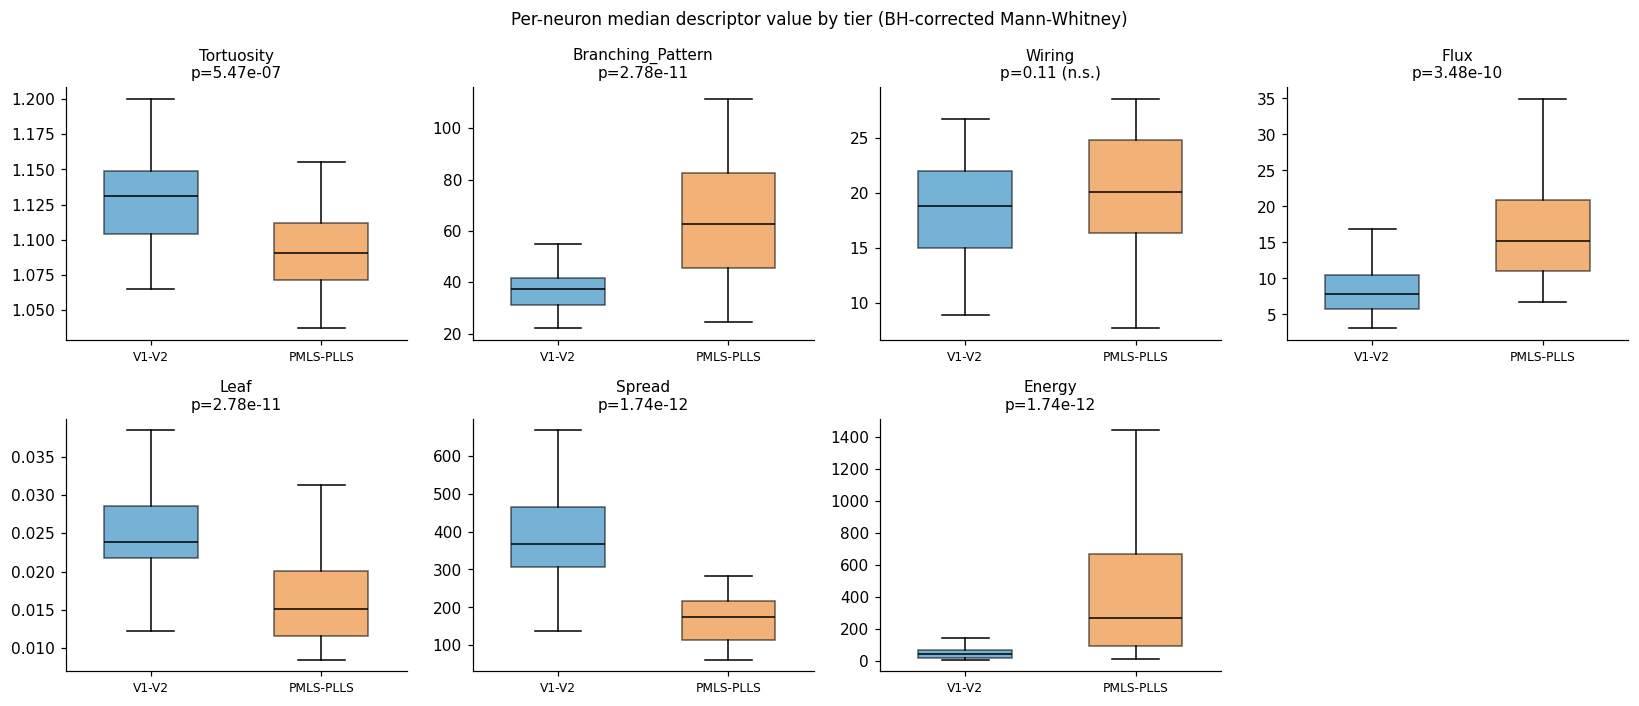

In [14]:
fig, axes = plt.subplots(2, 4, figsize=(15, 6.5))
for ax, name in zip(axes.ravel(), DESCRIPTOR_FUNCTIONS):
    sub = medians[medians['descriptor'] == name]
    groups = [sub.loc[sub['class'] == cls, 'median'].values for cls in TIER]
    # showfliers=False: outlier points are suppressed here for readability;
    # the published figure (make_figure4_boxplots.py) plots them.
    bp = ax.boxplot(groups, labels=list(TIER), patch_artist=True, widths=0.55,
                    showfliers=False)
    for patch, colour in zip(bp['boxes'], TIER.values()):
        patch.set_facecolor(colour); patch.set_alpha(0.6)
    for med in bp['medians']:
        med.set_color('k')
    p = p_lookup[name]
    p_str = f'p={p:.2e}' if p < 0.001 else (f'p={p:.3f}' if p < 0.05 else f'p={p:.2f} (n.s.)')
    ax.set_title(f'{name}\n{p_str}', fontsize=10)
    ax.tick_params(axis='x', labelsize=8)
axes.ravel()[-1].axis('off')
fig.suptitle('Per-neuron median descriptor value by tier (BH-corrected Mann-Whitney)',
             fontsize=11)
fig.tight_layout(); plt.show()


## 7. Is two clusters the right number?

The submitted analysis fixed k=2 by configuration. Sweeping k=2..8 on the
combined distance and reporting silhouette checks whether the six
previously reported extrastriate subtypes would appear at a finer cut.


,silhouette,ARI_vs_tier
k,,
2,0.3762,0.4497
3,0.2251,0.3122
4,0.2238,0.2743
5,0.1593,0.5112
6,0.1612,0.5156
7,0.1706,0.4900
8,0.1718,0.4888


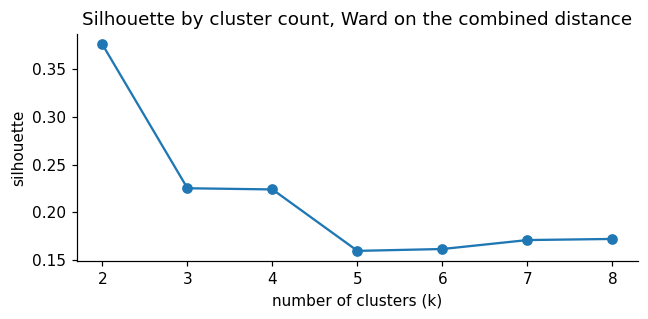

best k by silhouette: 2


In [15]:
rows = []
for k in range(2, 9):
    predicted = ward_clusters(combined, k)
    rows.append({'k': k,
                'silhouette': silhouette_score(combined.values, predicted, metric='precomputed'),
                'ARI_vs_tier': adjusted_rand_score(labels, predicted)})
sweep = pd.DataFrame(rows).set_index('k')
display(sweep.style.format('{:.4f}'))

fig, ax = plt.subplots(figsize=(6, 3))
ax.plot(sweep.index, sweep['silhouette'], marker='o')
ax.set_xlabel('number of clusters (k)'); ax.set_ylabel('silhouette')
ax.set_title('Silhouette by cluster count, Ward on the combined distance')
fig.tight_layout(); plt.show()

best_k = sweep['silhouette'].idxmax()
print(f'best k by silhouette: {best_k}')


> Table 1's resampling-stability row (400 replicates, 80% subsampling) is
> not run here, because it is stochastic and a different random draw gives
> different decimals from identical code — which does not sit well next to
> figures that reproduce exactly. It is implemented as a standalone script,
> `analysis/supporting/run_representation_stability_vs_morphometric.py`; run
> it directly if you want to see it. Its docstring explains what it does and
> does not establish: the method as Table 1's caption states it, not a
> recovery of the original run, since no script producing that table's exact
> values could be located anywhere in this repository or elsewhere on the
> machine this analysis was prepared on.


## 8. Tier or area?

Distance-based PERMANOVA on the combined matrix, 4999 permutations,
partitioning variance between cortical tiers and among the three mid-level
areas taken on their own.


In [16]:
perm = pd.read_csv(PLOTS / 'variance_partition' / 'permanova_variance_partition.csv')
tier = perm[perm['contrast'].str.startswith('between tier')].iloc[0]
area = perm[perm['contrast'].str.startswith('among areas')].iloc[0]
display(perm.style.format({'R2': '{:.4f}', 'pseudo_F': '{:.2f}', 'p_perm': '{:.4f}'}))
print(f'tier explains {tier.R2:.1%} (p = {tier.p_perm}), '
      f'area {area.R2:.1%} (p = {area.p_perm}); ratio {tier.R2/area.R2:.1f}x')


,contrast,n,groups,R2,pseudo_F,p_perm
0,between tier (V1/V2 vs extrastriate),117,2,0.2526,38.87,0.0002
1,among areas within extrastriate (PMLS/PLLS/21A),50,3,0.0264,0.64,0.5892


tier explains 25.3% (p = 0.0002), area 2.6% (p = 0.5892); ratio 9.6x


## 9. Neurons that cross tiers

Some mid-level neurons fall inside the V1/V2 cluster. Whether they come
from one area or from all three decides whether this is an area effect or
a shared morphological type.


In [17]:
from neurotopo.area_labels import infer_area_label
classes['area'] = [infer_area_label(n) for n in classes.index]

share_v1v2 = {cl: (labels[assign_d['dendrogram_cluster'].to_numpy() == cl] == 'V1-V2').mean()
              for cl in assign_d['dendrogram_cluster'].unique()}
v1v2_cluster = max(share_v1v2, key=share_v1v2.get)

mid = classes[classes['class'] == 'PMLS-PLLS'].index
assign_lookup = assign_d.set_index('neuron_name')['dendrogram_cluster']
crossers = [n for n in mid if n in assign_lookup.index and assign_lookup[n] == v1v2_cluster]

by_area = classes.loc[crossers, 'area'].value_counts()
totals = classes.loc[mid, 'area'].value_counts()
table = pd.DataFrame({'in V1/V2 cluster': by_area, 'total': totals}).fillna(0).astype(int)
print(f'{len(crossers)} of {len(mid)} mid-level neurons sit in the V1/V2 cluster')
print(table.to_string())


19 of 50 mid-level neurons sit in the V1/V2 cluster
      in V1/V2 cluster  total
area                         
21A                  4     10
PLLS                 6     20
PMLS                 9     20


## 10. Values reported in the paper


In [18]:
checks = [
    ('neurons',                     len(classes),     117),
    ('descriptors',                 len(descriptors), 7),
    ('detection rate, lowest',      min(weights.values()), 67),
    ('detection rate, highest',     max(weights.values()), 85),
    ('ARI, descriptors',            ari_d,             0.450),
    ('silhouette, descriptors',     table1.loc['Silhouette', 'Topological descriptors'], 0.267),
    ('mid-level in V1/V2 cluster',  len(crossers),     19),
    ('PERMANOVA tier R2',           tier.R2,           0.253),
    ('PERMANOVA area R2',           area.R2,           0.026),
]
rows = [{'quantity': n, 'computed': round(float(g), 4), 'in paper': e,
         'agrees': 'yes' if abs(float(g)-float(e)) <= max(0.001, abs(e)*0.01) else 'NO'}
        for n, g, e in checks]
result = pd.DataFrame(rows).set_index('quantity')
display(result)
print('all agree' if (result['agrees'] == 'yes').all() else 'see NO rows above')


,computed,in paper,agrees
quantity,,,
neurons,117.0000,117.000,yes
descriptors,7.0000,7.000,yes
"detection rate, lowest",67.0709,67.000,yes
"detection rate, highest",85.0299,85.000,yes
"ARI, descriptors",0.4497,0.450,yes
"silhouette, descriptors",0.2667,0.267,yes
mid-level in V1/V2 cluster,19.0000,19.000,yes
PERMANOVA tier R2,0.2526,0.253,yes
PERMANOVA area R2,0.0264,0.026,yes


all agree


## 11. Running this on your own data

Put reconstructions in `data/<name>/<class>/*.swc`, one subfolder per group,
set `PROJECT_NAME = '<name>'` in `config.py`, then either rerun this notebook
or use the pipeline directly:

```powershell
$env:PYTHONIOENCODING = 'utf-8'
$env:NEUROTOPO_RUN = 'my_run'
python reproduce_paper.py all
```

The descriptors assume nothing about species or brain area. Class labels
are used only for the detection weights and for scoring a clustering; the
step functions themselves are computed without them.
